[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammad-zainal-muttaqin/NulisBuku/blob/main/website/notebooks/ch06.ipynb)

Notebook Bab 6 ini punya dua bagian. Bagian **Demo** tinggal Anda jalankan lalu amati keluarannya; bagian **Mini Project** berisi soal dan data yang Anda kerjakan sendiri.

Fitur turunan (rasio, agregasi riwayat, bobot kebaruan, dan encoding waktu) sering mengekspos pola yang tak tertangkap model dari kolom mentah.


## Persiapan


In [1]:
import os
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')


from pathlib import Path
import json
import urllib.request
import urllib.parse

DATA_BASE_URL = 'https://raw.githubusercontent.com/muhammad-zainal-muttaqin/NulisBuku/main/website/notebooks/data/section1'


def section_data_dir(name):
    """Folder data Bagian 1: pakai salinan lokal bila ada; jika tidak (mis. di
    Google Colab), unduh berkas dari repo GitHub sesuai manifest."""
    for base in (Path('data/section1'), Path('../data/section1')):
        if (base / name).exists():
            return base / name
    cache = Path('_nb_data') / name
    if not (cache / 'manifest.json').exists():
        cache.mkdir(parents=True, exist_ok=True)
        base_url = DATA_BASE_URL + '/' + name
        manifest = json.loads(urllib.request.urlopen(base_url + '/manifest.json').read().decode('utf-8'))
        for rel in manifest:
            dest = cache / rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            if not dest.exists():
                url = base_url + '/' + '/'.join(urllib.parse.quote(seg) for seg in rel.split('/'))
                urllib.request.urlretrieve(url, dest)
        (cache / 'manifest.json').write_text(json.dumps(manifest), encoding='utf-8')
    return cache


## Section 1 - Demo: Fitur Turunan dari Event Log Online Retail


## Data: transaksi menjadi tabel pelanggan

Kita memakai snapshot UCI Online Retail yang sudah direlasionalisasi. Baris transaksi dan invoice diringkas menjadi tabel pelanggan pada beberapa `index_time`. Semua fitur dihitung dari kejadian sebelum `index_time`; target `future_active_60d` melihat apakah pelanggan punya invoice positif dalam 60 hari sesudahnya.


In [2]:
DATA_DIR = section_data_dir('ch06_online_retail')
features = pd.read_parquet(DATA_DIR / 'customer_cutoff_features.parquet')
stats = json.loads((DATA_DIR / 'verified_stats.json').read_text(encoding='utf-8'))

print(f"Line-item rows known-customer: {stats['line_item_rows_known_customer']:,}")
print(f"Invoice rows: {stats['invoice_rows_known_customer']:,} | Customers: {stats['customer_rows']:,}")
print(f"Customer/index-time rows: {stats['cutoff_feature_rows']:,}")
print('Cutoffs:', ', '.join(stats['cutoffs']))
print(f"Target future_active_60d rate: {stats['future_active_60d_rate_all']:.3f}")

summary = features.groupby('index_time').agg(
    rows=('CustomerID', 'size'),
    active_rate=('future_active_60d', 'mean'),
    median_gross_90d=('gross_value_90d', 'median'),
    median_days_since_last=('days_since_last_invoice', 'median'),
)
print()
print('Ringkasan per cutoff:')
print(summary.to_string(float_format=lambda x: f'{x:,.3f}'))


Line-item rows known-customer: 406,829
Invoice rows: 22,190 | Customers: 4,372
Customer/index-time rows: 20,603
Cutoffs: 2011-04-01, 2011-05-01, 2011-06-01, 2011-07-01, 2011-08-01, 2011-09-01, 2011-10-01
Target future_active_60d rate: 0.428

Ringkasan per cutoff:
            rows  active_rate  median_gross_90d  median_days_since_last
index_time                                                             
2011-04-01  2171        0.444           308.550                  36.000
2011-05-01  2488        0.445           294.845                  43.000
2011-06-01  2758        0.419           264.645                  50.000
2011-07-01  2996        0.380           228.525                  51.000
2011-08-01  3189        0.399           196.000                  60.000
2011-09-01  3355        0.437           138.320                  72.000
2011-10-01  3646        0.467           166.585                  64.000


## Baseline sejarah mentah vs fitur turunan

Baseline hanya memakai lima ringkasan 90 hari. Versi turunan menambahkan rasio, return rate, bobot kebaruan, dan encoding siklik bulan. Modelnya sama; yang berubah hanya representasi fitur.


           representasi  jumlah_fitur  ROC_AUC
5 fitur sejarah 90 hari             5   0.7224
          fitur turunan            14   0.7307


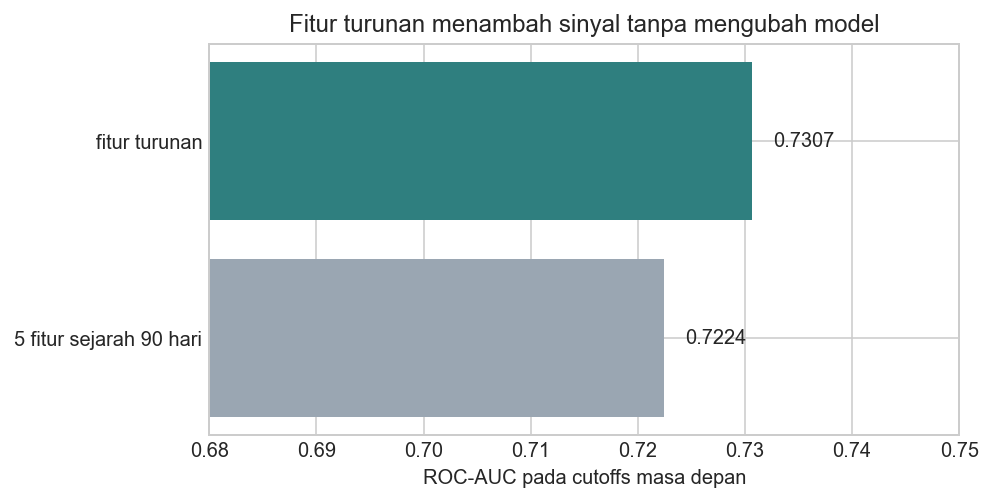

In [3]:
base_cols = stats['base_features']
derived_cols = stats['derived_features']
train = features[features['index_time'] <= pd.Timestamp('2011-08-01')]
test = features[features['index_time'] >= pd.Timestamp('2011-09-01')]

def auc_for(cols):
    model = HistGradientBoostingClassifier(
        max_iter=160, learning_rate=0.06, max_leaf_nodes=15, random_state=RANDOM_STATE
    )
    model.fit(train[cols], train['future_active_60d'])
    pred = model.predict_proba(test[cols])[:, 1]
    return roc_auc_score(test['future_active_60d'], pred)

score_df = pd.DataFrame([
    {'representasi': '5 fitur sejarah 90 hari', 'jumlah_fitur': len(base_cols), 'ROC_AUC': auc_for(base_cols)},
    {'representasi': 'fitur turunan', 'jumlah_fitur': len(derived_cols), 'ROC_AUC': auc_for(derived_cols)},
])
print(score_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(score_df['representasi'], score_df['ROC_AUC'], color=['#9aa6b2', '#2f7f7f'])
ax.set_xlim(0.68, 0.75)
ax.set_xlabel('ROC-AUC pada cutoffs masa depan')
ax.set_title('Fitur turunan menambah sinyal tanpa mengubah model')
for i, value in enumerate(score_df['ROC_AUC']):
    ax.text(value + 0.002, i, f'{value:.4f}', va='center')
plt.tight_layout()
plt.show()


## Gambar 6.5: pertumbuhan jumlah fitur

Fitur turunan berguna, tetapi kombinasi otomatis dapat tumbuh cepat. Plot berikut memakai perhitungan jumlah kolom, bukan dataset retail, karena tujuannya memperlihatkan risiko *feature explosion* secara umum.


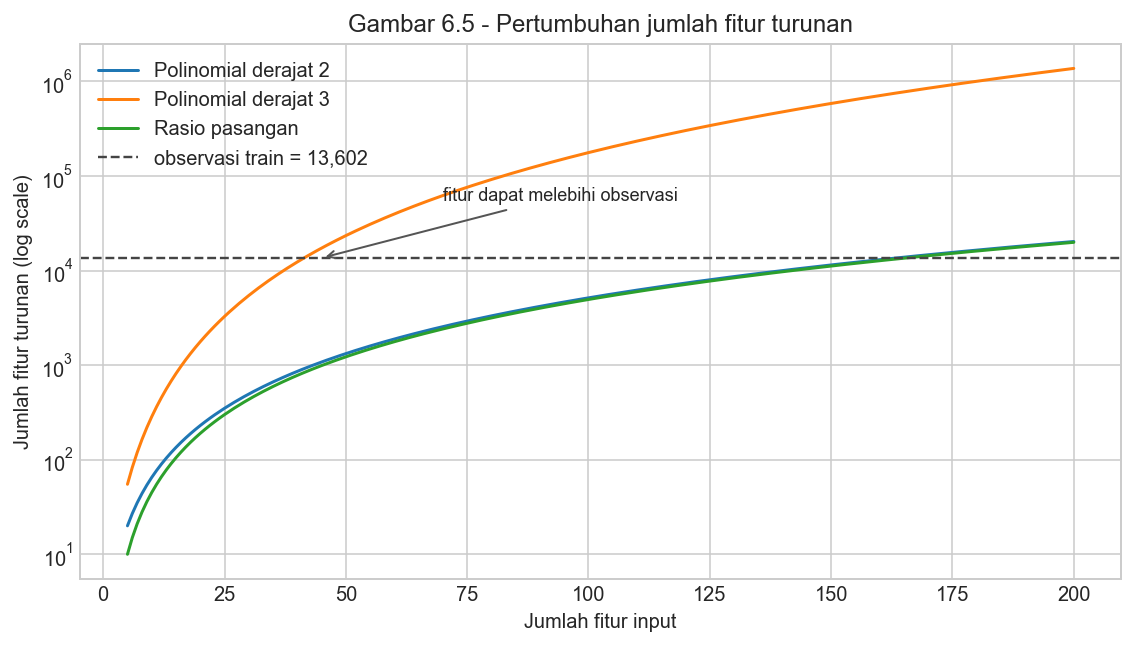

In [4]:
d = np.arange(5, 201)
degree2 = d + (d * (d - 1) // 2) + d
degree3 = ((d + 3) * (d + 2) * (d + 1) // 6) - 1
pairwise_ratios = d * (d - 1) // 2
n_observasi = len(train)

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(d, degree2, label='Polinomial derajat 2')
ax.plot(d, degree3, label='Polinomial derajat 3')
ax.plot(d, pairwise_ratios, label='Rasio pasangan')
ax.axhline(n_observasi, color='#444444', linestyle='--', linewidth=1.2, label=f'observasi train = {n_observasi:,}')
ax.set_yscale('log')
ax.set_xlabel('Jumlah fitur input')
ax.set_ylabel('Jumlah fitur turunan (log scale)')
ax.set_title('Gambar 6.5 - Pertumbuhan jumlah fitur turunan')
ax.legend(loc='upper left')
ax.annotate('fitur dapat melebihi observasi', xy=(45, n_observasi), xytext=(70, n_observasi * 4),
            arrowprops={'arrowstyle': '->', 'color': '#555555'}, fontsize=9)
plt.tight_layout()
plt.show()


>
> 🔎 **Amati.** Fitur turunan menaikkan ROC-AUC pada split waktu masa depan, tetapi kenaikannya kecil dan harus dibaca sebagai bukti empiris, bukan jaminan universal. Rasio, bobot kebaruan, dan fitur siklik membantu karena menjawab pertanyaan yang berbeda dari total 90 hari mentah. Pada saat yang sama, Gambar 6.5 mengingatkan bahwa membuat semua kombinasi fitur tanpa hipotesis dapat segera menghasilkan lebih banyak kolom daripada observasi.


## Section 2 - Mini Project

## Soal

Anda diberi data transaksi dengan kolom `tanggal` (hari ke-0..364), `jumlah_item`, `total_belanja`, dan `poin_loyalitas`. Targetnya `pakai_promo` (1/0).

Tugas:

1. Buat minimal 5 fitur turunan (misalnya harga rata-rata per item, fitur musiman dari `tanggal` via sin/cos, rasio poin terhadap belanja).
2. Bandingkan model pada fitur mentah vs fitur mentah + turunan.
3. Tunjukkan mana fitur turunan yang paling menaikkan skor.

**Luaran:** kode pembentukan fitur, perbandingan skor, dan 2-3 kalimat kesimpulan.

**Kriteria penilaian:** (a) minimal 5 fitur turunan; (b) encoding waktu yang benar (siklik); (c) evaluasi CV yang adil.

In [5]:
# DATA AWAL (jangan diubah) - transaksi ritel.
n = 2500
tanggal = rng.integers(0, 365, n)
jumlah_item = rng.integers(1, 30, n)
total_belanja = jumlah_item * rng.gamma(2.0, 25000, n)
poin = rng.gamma(2.0, 100, n)
musim = np.sin(2 * np.pi * tanggal / 365)
logit = 1.5 * musim + 0.0000015 * total_belanja - 0.008 * poin
pakai_promo = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
trx = pd.DataFrame({'tanggal': tanggal, 'jumlah_item': jumlah_item,
                    'total_belanja': total_belanja.round(0), 'poin_loyalitas': poin.round(1),
                    'pakai_promo': pakai_promo})
print('Data:', trx.shape)
trx.head()


Data: (2500, 5)


In [6]:
# Kerjakan di sini.
# Petunjuk: buat kolom turunan di DataFrame, lalu bandingkan cross_val_score sebelum vs sesudah.
